In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [6]:
# Load the dataset
from google.colab import files

uploaded = files.upload()

Saving superstore.csv to superstore (1).csv


In [7]:
uploaded.keys()
df= pd.read_csv('superstore.csv')
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,00:00.0,CA-2011-146969,...,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


***Q1: Data Cleaning:***

Q1  i. Count and handle Missing values.

In [8]:
missing_counts = df.isnull().sum()
cols_with_missing = missing_counts[missing_counts > 0]
print("Missing values before cleaning:", cols_with_missing)

# Handling missing values
df['Shipping.Cost'] = df['Shipping.Cost'].fillna(df['Shipping.Cost'].median())

# For categorical column State, we use a placeholder 'Unknown'
df['State'] = df['State'].fillna('Unknown')

# Final check
print("\nMissing values after cleaning:", df.isnull().sum().sum())

Missing values before cleaning: Shipping.Cost    5
State            3
dtype: int64

Missing values after cleaning: 0


Q1 ii. Deal with Duplicate values

In [9]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

# Re-checking to confirm
final_count = df.duplicated().sum()
print(f"Number of duplicate rows after removal: {final_count}")

Number of duplicate rows found: 0
Number of duplicate rows after removal: 0


Q1 iii. Delete unknown columns if present.

In [10]:
cols_to_drop = ['记录数']

df_cleaned = df.drop(columns=cols_to_drop)

print(f"Columns before deletion: {len(df.columns)}")
print(f"Columns after deletion: {len(df_cleaned.columns)}")
print("\nRemaining columns:")
print(df_cleaned.columns.tolist())

Columns before deletion: 27
Columns after deletion: 26

Remaining columns:
['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name', 'Discount', 'Market', 'Order.Date', 'Order.ID', 'Order.Priority', 'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID', 'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State', 'Sub.Category', 'Year', 'Market2', 'weeknum']


Q1 iv. Check shape, size, and datatypes of the dataset features.

In [11]:
df = df.drop(columns=['记录数'])
shape = df.shape
size = df.size
dtypes = df.dtypes

print(f"Shape of the dataset: {shape}")
print(f"Size of the dataset: {size}")
print("\nDatatypes of the features:")
print(dtypes)

Shape of the dataset: (51290, 26)
Size of the dataset: 1333540

Datatypes of the features:
Category           object
City               object
Country            object
Customer.ID        object
Customer.Name      object
Discount          float64
Market             object
Order.Date         object
Order.ID           object
Order.Priority     object
Product.ID         object
Product.Name       object
Profit            float64
Quantity            int64
Region             object
Row.ID              int64
Sales               int64
Segment            object
Ship.Date          object
Ship.Mode          object
Shipping.Cost     float64
State              object
Sub.Category       object
Year                int64
Market2            object
weeknum             int64
dtype: object


***Q2: Perform Univariate Analysis across all numerical features***

Q2 i. Which features seem useless in the analysis? Explain why?

Numerical features identified: ['Discount', 'Profit', 'Quantity', 'Row.ID', 'Sales', 'Shipping.Cost', 'Year', 'weeknum']


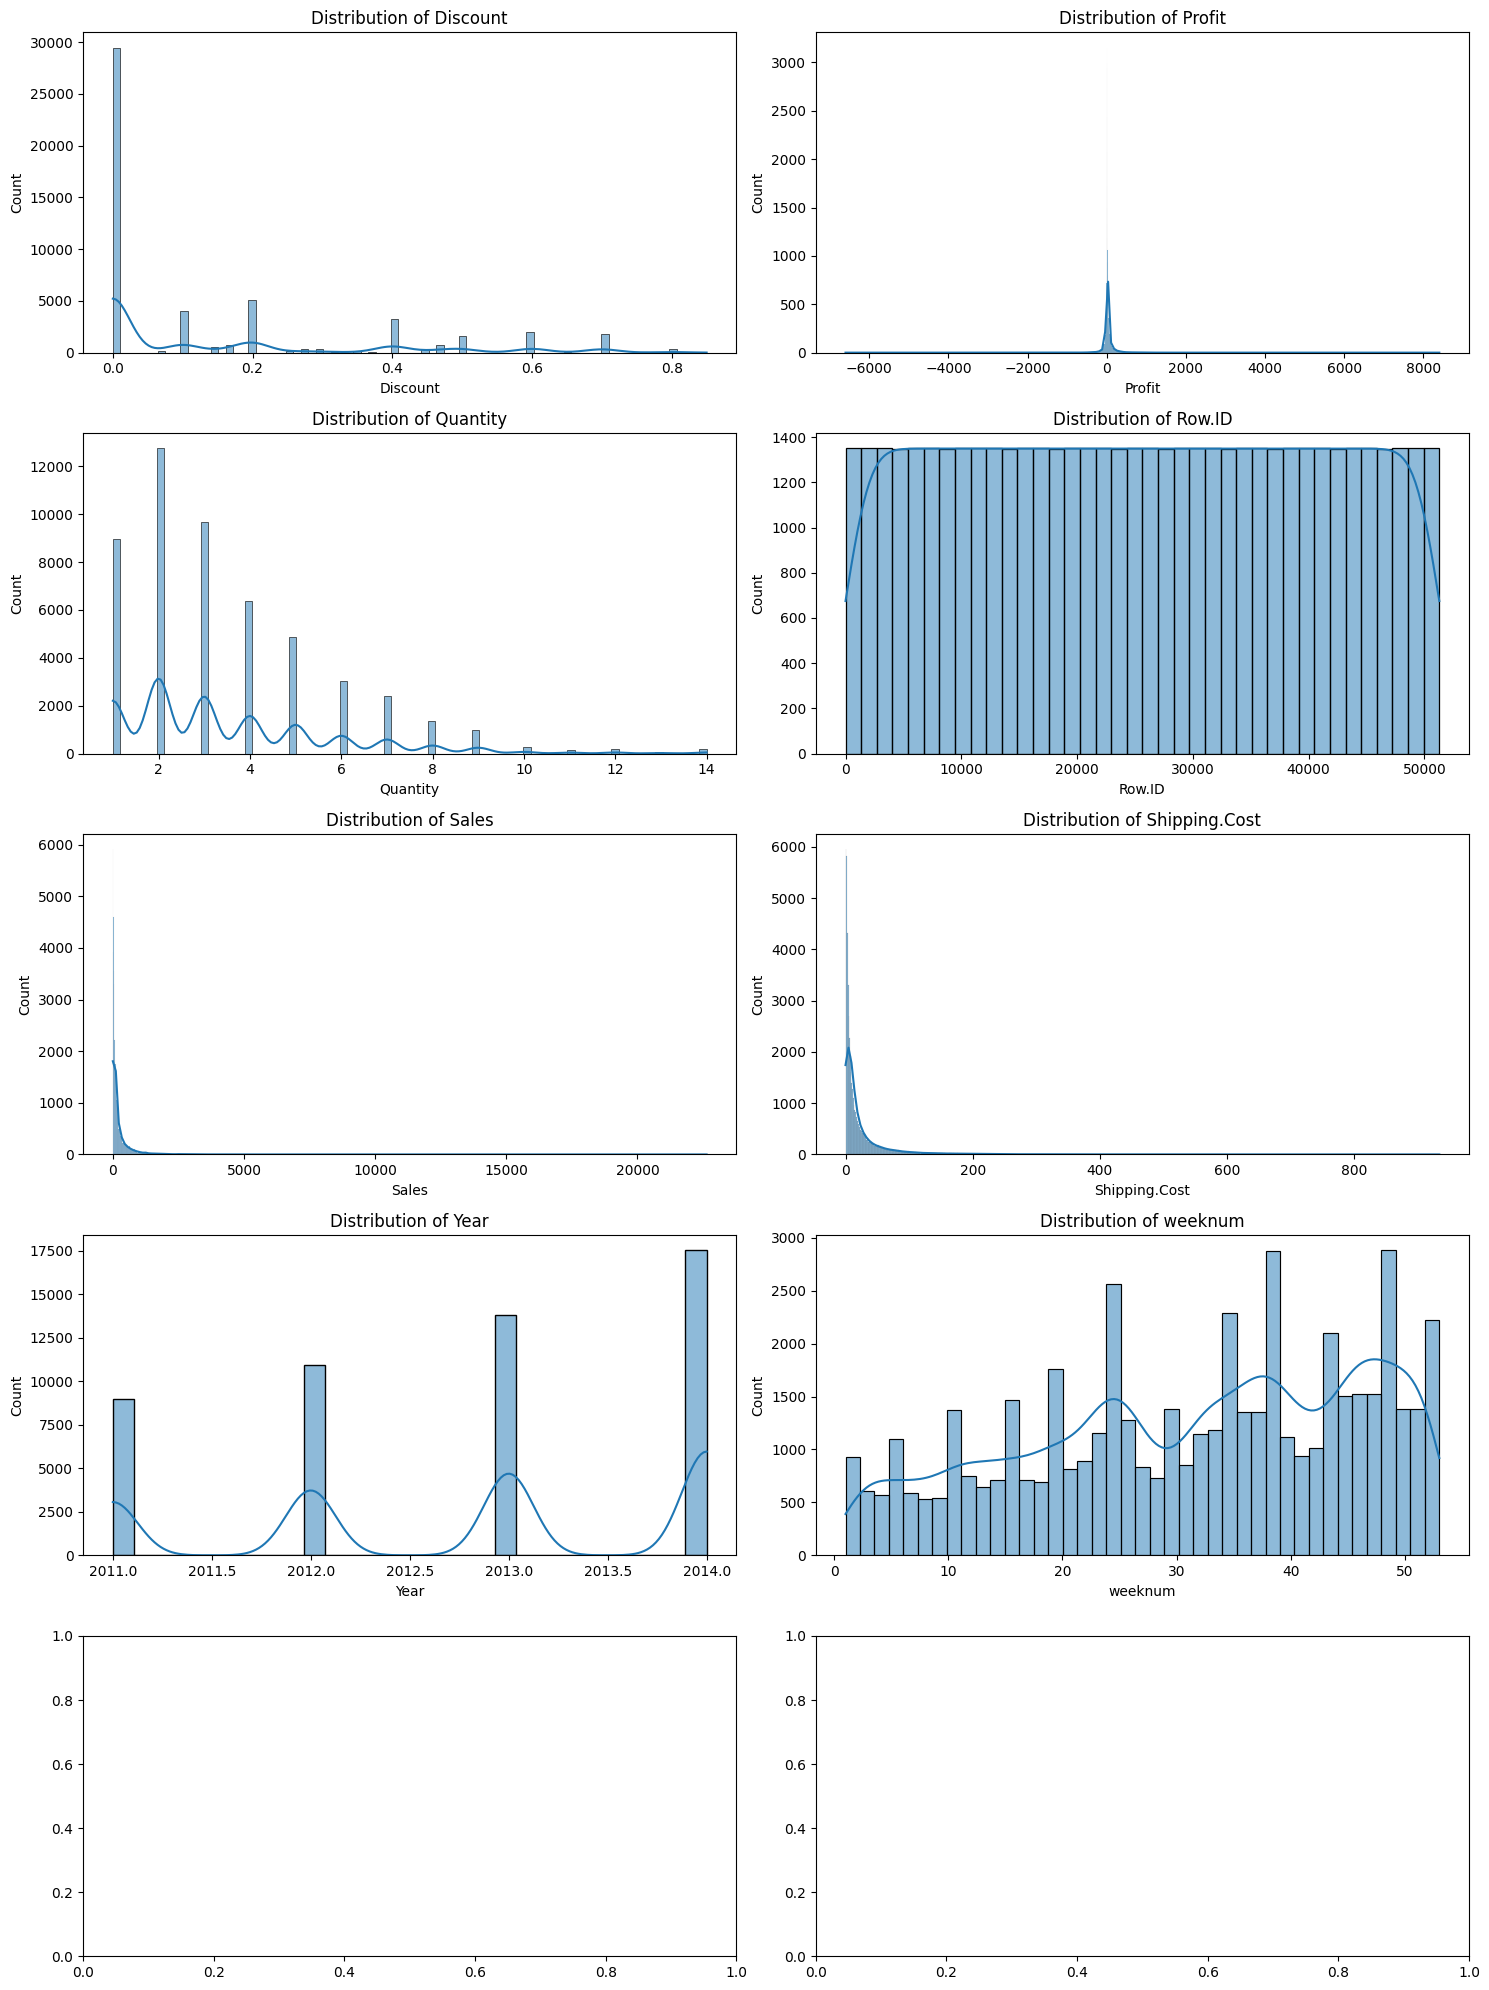

In [12]:
if '记录数' in df.columns:
    df = df.drop(columns=['记录数'])
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Numerical features identified: {numerical_features}")


fig, axes = plt.subplots(len(numerical_features)//2 + 1, 2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

Q2 ii. Which features are uniformly distributed or normally distributed?

If skewness in close to 0 and kutosis is close to 0 then NORMALLY DISTRIBUTED DATA
If skewness in close to 0 and kutosis is negative (Typically around -1.2) then UNIFORMLY DISTRIBUTED DATA
         Feature      Skewness    Kurtosis
0       Discount  1.387734e+00    0.716496
1         Profit  4.157067e+00  291.382565
2       Quantity  1.360328e+00    2.275550
3         Row.ID  9.010156e-18   -1.200000
4          Sales  8.137743e+00  176.705679
5  Shipping.Cost  5.863084e+00   50.015567
6           Year -3.445052e-01   -1.222031
7        weeknum -3.424405e-01   -0.981978


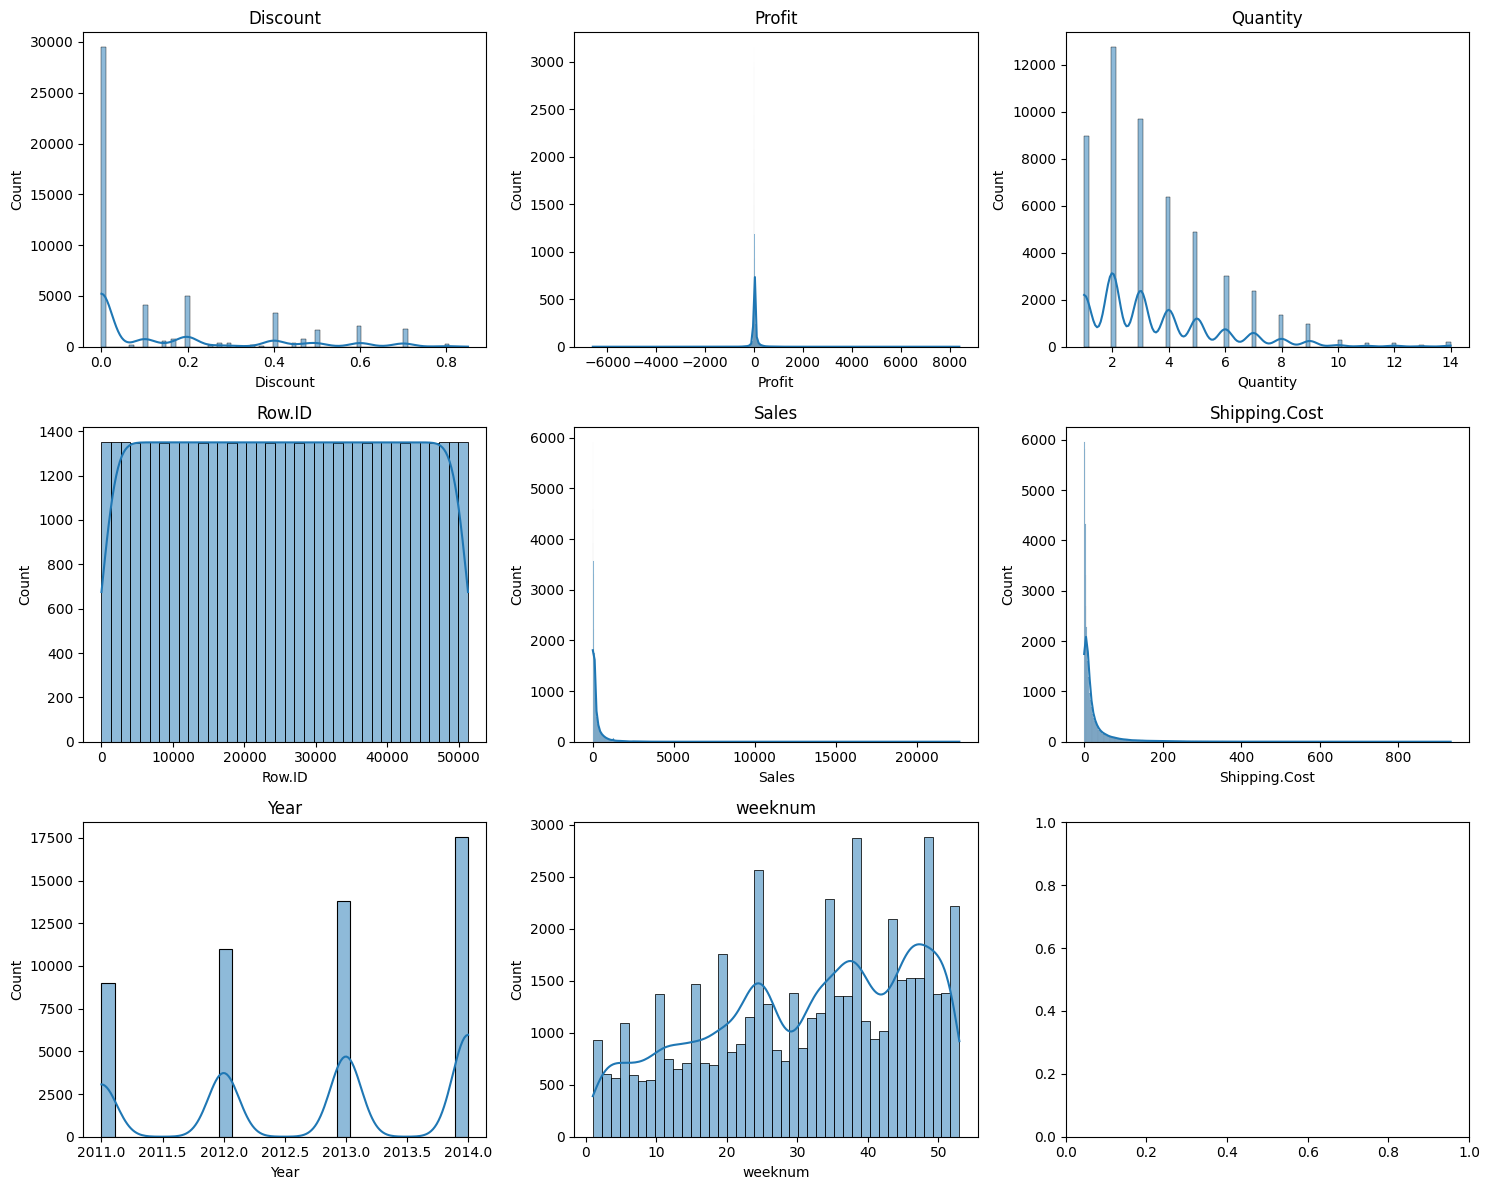

In [25]:
from scipy.stats import skew, kurtosis

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if '记录数' in num_cols:
    num_cols.remove('记录数')

stats = []
for col in num_cols:
    stats.append({
        'Feature': col,
        'Skewness': skew(df[col].dropna()),
        'Kurtosis': kurtosis(df[col].dropna())
    })

stats_df = pd.DataFrame(stats)
print("If skewness in close to 0 and kutosis is close to 0 then NORMALLY DISTRIBUTED DATA")
print("If skewness in close to 0 and kutosis is negative (Typically around -1.2) then UNIFORMLY DISTRIBUTED DATA")
print(stats_df)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()

Q2 iii. Which features are right-skewed/left-skewed? What does this signify?

In [14]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if '记录数' in num_cols:
    num_cols.remove('记录数')

skewness_results = []
for col in num_cols:
    val = skew(df[col].dropna())
    if val > 0.5:
        classification = "Right-skewed (+)"
    elif val < -0.5:
        classification = "Left-skewed (-)"
    else:
        classification = "Symmetrical"
    skewness_results.append({'Feature': col, 'Skewness': round(val, 2), 'Type': classification})

skew_df = pd.DataFrame(skewness_results)
print(skew_df)

         Feature  Skewness              Type
0       Discount      1.39  Right-skewed (+)
1         Profit      4.16  Right-skewed (+)
2       Quantity      1.36  Right-skewed (+)
3         Row.ID      0.00       Symmetrical
4          Sales      8.14  Right-skewed (+)
5  Shipping.Cost      5.86  Right-skewed (+)
6           Year     -0.34       Symmetrical
7        weeknum     -0.34       Symmetrical


**Significance of Right-Skewed:** It indicates that most of the data values are concentrated on the lower end, and there are some unusually high values.

**Significance of Left-Skewed:** It indicates that most of the data values are concentrated on the higher end, and there are some unusually low values.

Q2 iv. Which features have a high number of outliers, and discuss the impact.

In [15]:
num_cols = ['Sales', 'Profit', 'Quantity', 'Discount', 'Shipping.Cost']

outlier_results = []

for col in num_cols:
    data = df[col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data < lower_bound) | (data > upper_bound)]
    outlier_count = len(outliers)
    percentage = (outlier_count / len(data)) * 100

    outlier_results.append({
        'Feature': col,
        'Outlier Count': outlier_count,
        'Percentage (%)': round(percentage, 2),
        'Max Value': data.max(),
        'Min Value': data.min()
    })

outlier_df = pd.DataFrame(outlier_results).sort_values(by='Outlier Count', ascending=False)
print(outlier_df)

         Feature  Outlier Count  Percentage (%)  Max Value  Min Value
1         Profit           9755           19.02   8399.976  -6599.978
4  Shipping.Cost           5909           11.52    933.570      0.002
0          Sales           5655           11.03  22638.000      0.000
3       Discount           4172            8.13      0.850      0.000
2       Quantity            877            1.71     14.000      1.000


***Q3: Perform Univariate Analysis across all categorical features.***

Q3 i. Which features seem inaccurate and are not useful as categorical “insights” directly?

In [26]:
cat_cols = df.select_dtypes(include=['object']).columns

analysis = []
for col in cat_cols:
    analysis.append({
        'Feature': col,
        'Unique_Count': df[col].nunique(),
        'Sample_Values': df[col].unique()[:3]
    })

analysis_df = pd.DataFrame(analysis)
print(analysis_df)

inaccurate_cols = analysis_df[analysis_df['Unique_Count'] <= 1]['Feature'].tolist()
print(f"\nFeatures seem inaccurate and are not useful as categorical “insights” directly: {inaccurate_cols}")


           Feature  Unique_Count  \
0         Category             3   
1             City          3636   
2          Country           147   
3      Customer.ID          4873   
4    Customer.Name           795   
5           Market             7   
6       Order.Date             1   
7         Order.ID         25035   
8   Order.Priority             4   
9       Product.ID         10292   
10    Product.Name          3788   
11          Region            13   
12         Segment             3   
13       Ship.Date             1   
14       Ship.Mode             4   
15           State          1095   
16    Sub.Category            17   
17         Market2             6   

                                        Sample_Values  
0            [Office Supplies, Technology, Furniture]  
1             [Los Angeles, San Francisco, San Diego]  
2                    [United States, France, Germany]  
3                   [LS-172304, MV-174854, CS-121304]  
4     [Lycoris Saunders, Mark Van H

Q3 ii. What’s the issue with treating Customer Name as a categorical feature for modeling?

In [17]:
unique_names = df['Customer.Name'].nunique()
total_rows = len(df)
cardinality_ratio = unique_names / total_rows

customer_counts = df['Customer.Name'].value_counts()

print(f"Total Records: {total_rows}")
print(f"Unique Customer Names: {unique_names}")
print(f"Cardinality Ratio: {cardinality_ratio:.4f}")
print("\nTop 5 Customer Record Counts:")
print(customer_counts.head())
print("\nBottom 5 Customer Record Counts:")
print(customer_counts.tail())

Total Records: 51290
Unique Customer Names: 795
Cardinality Ratio: 0.0155

Top 5 Customer Record Counts:
Customer.Name
Muhammed Yedwab    108
Steven Ward        106
Bill Eplett        102
Gary Hwang         102
Patrick O'Brill    102
Name: count, dtype: int64

Bottom 5 Customer Record Counts:
Customer.Name
Catherine Glotzbach    35
David Bremer           34
Darren Budd            31
Nicole Brennan         31
Michael Oakman         29
Name: count, dtype: int64


**The issue with treating Customer Name as a categorical feature for modeling is amongst total 51290 customers, only 795 names are unique which is marking it's cardinality ration very low**

Q3 iii. Is the Category distribution balanced or skewed? Give a 1-line reason.

In [18]:
category_counts = df['Category'].value_counts()
category_percentage = df['Category'].value_counts(normalize=True) * 100

print(category_counts)
print(category_percentage)

Category
Office Supplies    31273
Technology         10141
Furniture           9876
Name: count, dtype: int64
Category
Office Supplies    60.972899
Technology         19.771885
Furniture          19.255215
Name: proportion, dtype: float64


**Yes. Category distribution is skewed**

**Reason:** "Office Supplies" is 60.972899 % (approximately 61%) of the total dataset, making it more than three times of the occuring of "Technology" (approximately 20%) or "Furniture" (approximately 19%).

Q3 iv. In Country, does one country dominate strongly? What does that imply about geographic bias?

In [19]:
country_counts = df['Country'].value_counts()
country_percentages = df['Country'].value_counts(normalize=True) * 100

# Get the top 5 to check dominance
top_countries = pd.DataFrame({
    'Count': country_counts.head(5),
    'Percentage (%)': country_percentages.head(5)
})

print(top_countries)

               Count  Percentage (%)
Country                             
United States   9994       19.485280
Australia       2837        5.531293
France          2827        5.511796
Mexico          2644        5.155001
Germany         2065        4.026126


**YES. one country dominate strongly : USA Total 19.5% of the dataset.**

**It implies that USA has the biggest consumer base and the market share.**

Q3 v. Is the City dataset concentrated in a few cities or spread out?

In [39]:
city_counts = df['City'].value_counts()
total_cities = len(city_counts)
total_records = len(df)

top_50_cities = city_counts.head(50)
top_50_share = (top_50_cities.sum() / total_records) * 100

print(f"Total Unique Cities: {total_cities}")
print(f"Total Records: {total_records}")
print(f"\nTop 10 Cities and their counts:\n{top_50_cities}")
print(f"\nPercentage of records in top 50 cities: {top_50_share:.2f}%")

Total Unique Cities: 3636
Total Records: 51290

Top 10 Cities and their counts:
City
New York City       915
Los Angeles         747
Philadelphia        537
San Francisco       510
Santo Domingo       443
Manila              432
Seattle             428
Houston             377
Tegucigalpa         362
Jakarta             337
Managua             336
Lagos               333
Istanbul            314
Chicago             314
Mexico City         300
Bangkok             287
London              281
Sydney              271
Cairo               248
Vienna              245
Melbourne           235
Columbus            222
San Salvador        221
Berlin              217
Gold Coast          201
Perth               198
Paris               187
Buenos Aires        184
Kinshasa            182
Ho Chi Minh City    179
Brisbane            178
Baghdad             173
Madrid              171
San Pedro Sula      171
San Diego           170
Springfield         163
Canberra            162
Adelaide            158
Dal

**The City dataset is concentrated in a few cities ( Percentage of records in top 50 cities: 25.55% )**

***Q4: Perform Bivariant Analysis for numerical-to-numerical features:***

Q4 i. Which two features are most strongly correlated?

Strongest Correlation Pair: ('Sales', 'Shipping.Cost')
Correlation Coefficient: 0.768073818316104

Correlation Matrix:
                  Sales    Profit  Quantity  Discount  Shipping.Cost  \
Sales          1.000000  0.484923  0.313580 -0.086728       0.768074   
Profit         0.484923  1.000000  0.104365 -0.316490       0.354441   
Quantity       0.313580  0.104365  1.000000 -0.019875       0.272645   
Discount      -0.086728 -0.316490 -0.019875  1.000000      -0.079061   
Shipping.Cost  0.768074  0.354441  0.272645 -0.079061       1.000000   
Year          -0.002902  0.002626 -0.005049 -0.005894      -0.003137   
weeknum        0.001947 -0.000182  0.020839 -0.000217       0.005340   

                   Year   weeknum  
Sales         -0.002902  0.001947  
Profit         0.002626 -0.000182  
Quantity      -0.005049  0.020839  
Discount      -0.005894 -0.000217  
Shipping.Cost -0.003137  0.005340  
Year           1.000000 -0.019627  
weeknum       -0.019627  1.000000  


/tmp/ipython-input-1110998916.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  strongest_value = sorted_pairs[0]


Text(0.5, 1.0, 'Correlation Heatmap of Numerical Features')

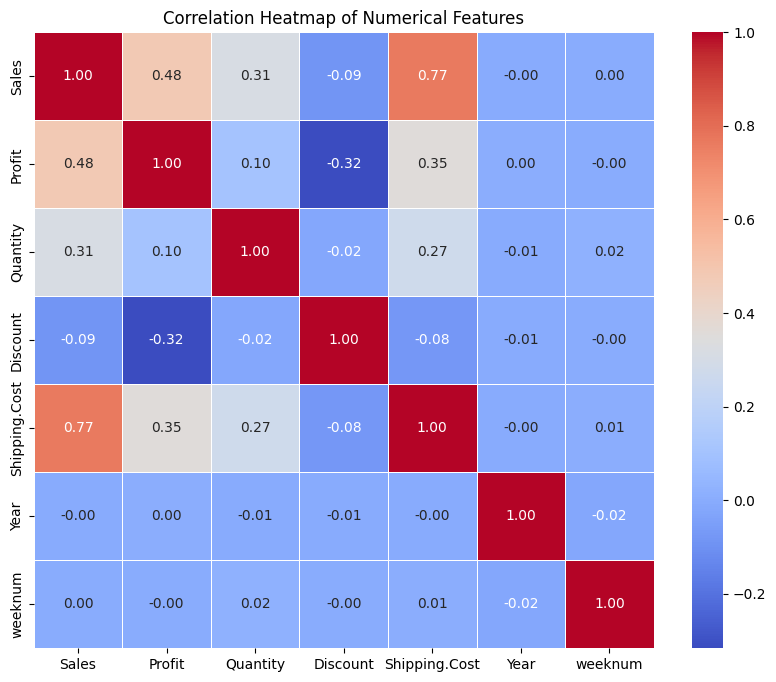

In [40]:
num_cols = ['Sales', 'Profit', 'Quantity', 'Discount', 'Shipping.Cost', 'Year', 'weeknum']
correlation_matrix = df[num_cols].corr()

corr_pairs = correlation_matrix.unstack()
sorted_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)].sort_values(ascending=False)
strongest_pair = sorted_pairs.index[0]
strongest_value = sorted_pairs[0]

print(f"Strongest Correlation Pair: {strongest_pair}")
print(f"Correlation Coefficient: {strongest_value}")

# Display the correlation matrix
print("\nCorrelation Matrix:")
print(correlation_matrix)

# Plotting the heatmap for Bivariate Analysis
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')

Q4 ii. Also name features that are negatively correlated.

In [41]:
num_cols = ['Sales', 'Profit', 'Quantity', 'Discount', 'Shipping.Cost', 'Year', 'weeknum']
correlation_matrix = df[num_cols].corr()
neg_corr = correlation_matrix.unstack()
neg_corr = neg_corr[neg_corr < 0].sort_values()
neg_corr_df = pd.DataFrame(neg_corr).reset_index()
neg_corr_df.columns = ['Feature 1', 'Feature 2', 'Correlation']
neg_corr_df['abs_corr'] = neg_corr_df['Correlation'].abs()
neg_corr_df = neg_corr_df.sort_values(by='abs_corr', ascending=False)
neg_corr_df = neg_corr_df.iloc[::2]

print(neg_corr_df[['Feature 1', 'Feature 2', 'Correlation']])

        Feature 1      Feature 2  Correlation
0          Profit       Discount    -0.316490
2        Discount          Sales    -0.086728
4   Shipping.Cost       Discount    -0.079061
6        Quantity       Discount    -0.019875
8         weeknum           Year    -0.019627
10       Discount           Year    -0.005894
12       Quantity           Year    -0.005049
14           Year  Shipping.Cost    -0.003137
16          Sales           Year    -0.002902
18        weeknum       Discount    -0.000217
20         Profit        weeknum    -0.000182


Q4 iii. If your goal is to understand profit, which are the most useful next bivariate checks? Perform them and give clear insights.

/tmp/ipython-input-828604584.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Profit', data=df, estimator='mean', palette='viridis')
/tmp/ipython-input-828604584.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Market', y='Profit', data=market_profit, palette='magma')
/tmp/ipython-input-828604584.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Discount', y='Profit', data=df, estimator='mean', ci=None, marker='o')
/tmp/ipython-input-828604584.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `l

Average Profit by Category:
Category
Technology         65.454958
Furniture          28.878567
Office Supplies    16.578961
Name: Profit, dtype: float64

Total Profit by Market:
Market
APAC      436000.04900
EU        372829.74150
US        286397.02170
LATAM     221643.48708
Africa     88871.63100
EMEA       43897.97100
Canada     17817.39000
Name: Profit, dtype: float64

Mean Profit at specific Discount levels (Top 5):
Discount
0.000     61.039514
0.002    125.762649
0.070    140.990022
0.100     63.683426
0.150     50.602409
Name: Profit, dtype: float64

Least Profitable Sub-Categories (Mean):
Sub.Category
Tables      -74.429023
Fasteners     4.762572
Labels        5.759982
Supplies      9.312686
Binders      11.776633
Name: Profit, dtype: float64


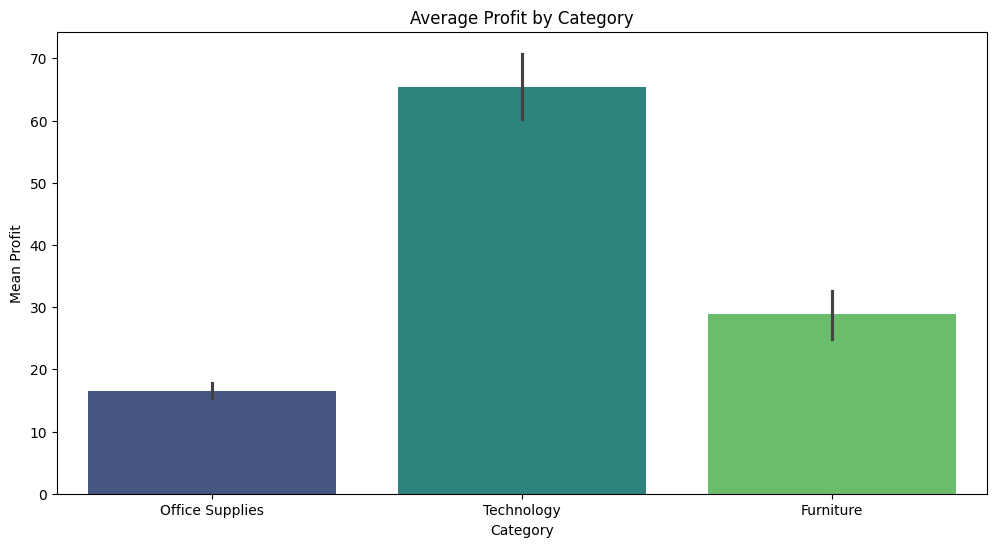

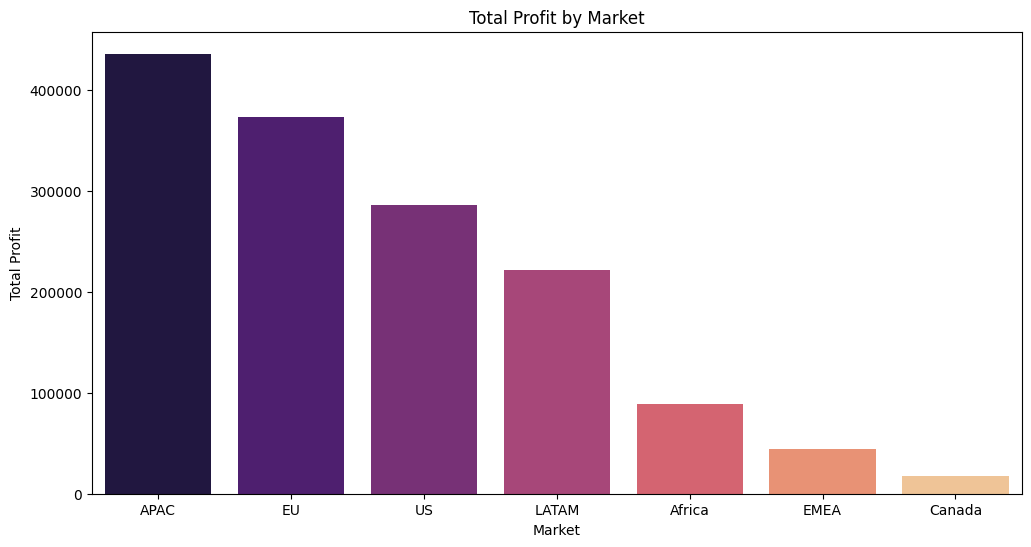

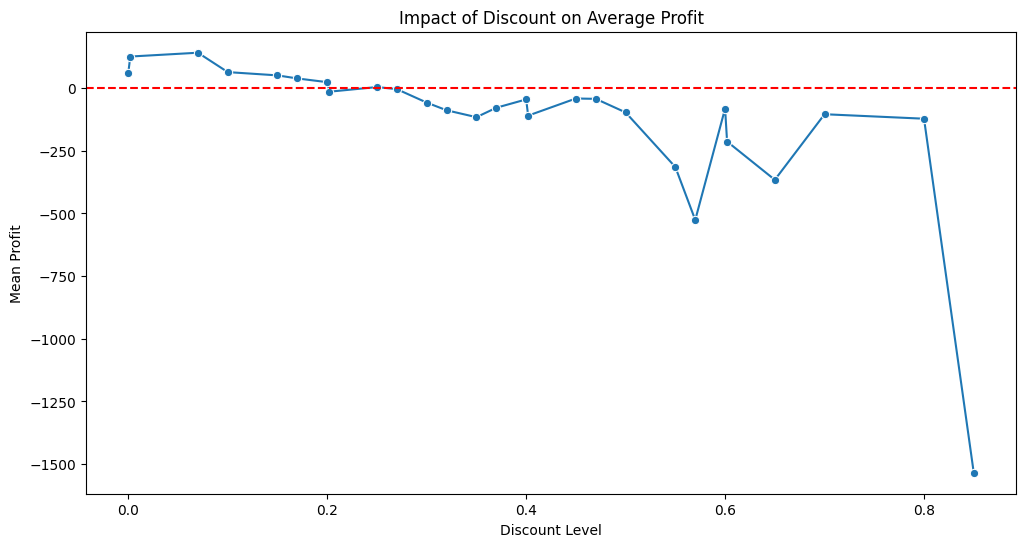

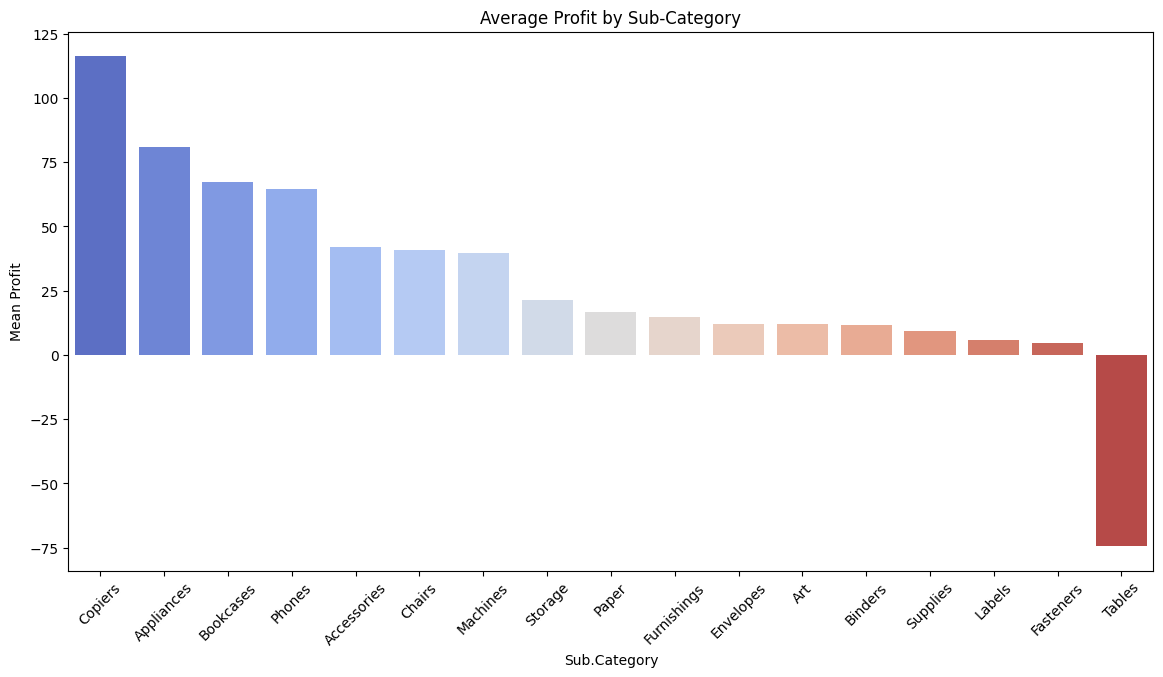

In [42]:
# 1. Profit vs Category
plt.figure(figsize=(12, 6))
sns.barplot(x='Category', y='Profit', data=df, estimator='mean', palette='viridis')
plt.title('Average Profit by Category')
plt.ylabel('Mean Profit')

# 2. Profit vs Market
plt.figure(figsize=(12, 6))
market_profit = df.groupby('Market')['Profit'].sum().sort_values(ascending=False).reset_index()
sns.barplot(x='Market', y='Profit', data=market_profit, palette='magma')
plt.title('Total Profit by Market')
plt.ylabel('Total Profit')

# 3. Profit vs Discount
plt.figure(figsize=(12, 6))
sns.lineplot(x='Discount', y='Profit', data=df, estimator='mean', ci=None, marker='o')
plt.axhline(0, color='red', linestyle='--')
plt.title('Impact of Discount on Average Profit')
plt.xlabel('Discount Level')
plt.ylabel('Mean Profit')

# 4. Profit vs Sub-Category
plt.figure(figsize=(14, 7))
subcat_profit = df.groupby('Sub.Category')['Profit'].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='Sub.Category', y='Profit', data=subcat_profit, palette='coolwarm')
plt.xticks(rotation=45)
plt.title('Average Profit by Sub-Category')
plt.ylabel('Mean Profit')

# Print summary
print("Average Profit by Category:")
print(df.groupby('Category')['Profit'].mean().sort_values(ascending=False))

print("\nTotal Profit by Market:")
print(df.groupby('Market')['Profit'].sum().sort_values(ascending=False))

print("\nMean Profit at specific Discount levels (Top 5):")
print(df.groupby('Discount')['Profit'].mean().head(5))

print("\nLeast Profitable Sub-Categories (Mean):")
print(df.groupby('Sub.Category')['Profit'].mean().sort_values().head(5))

Q4 iv. Look for Time Effects Clues. Mention any information you find about the time relationship with any feature.

Yearly Summary:
   Year    Sales        Profit  Shipping.Cost
0  2011  2259511  248940.81154      27.148260
1  2012  2677493  307415.27910      25.861232
2  2013  3405860  406935.23018      26.418458
3  2014  4300041  504165.97046      26.268819

Top 5 Weeks by Average Sales:
    weeknum       Sales     Profit  Shipping.Cost
1         2  284.216364  26.767053      27.932545
39       40  274.556351  40.229989      26.609886
11       12  273.320805  31.726422      25.891474
50       51  273.268646  31.482283      29.748537
41       42  272.047198  32.225979      29.347140


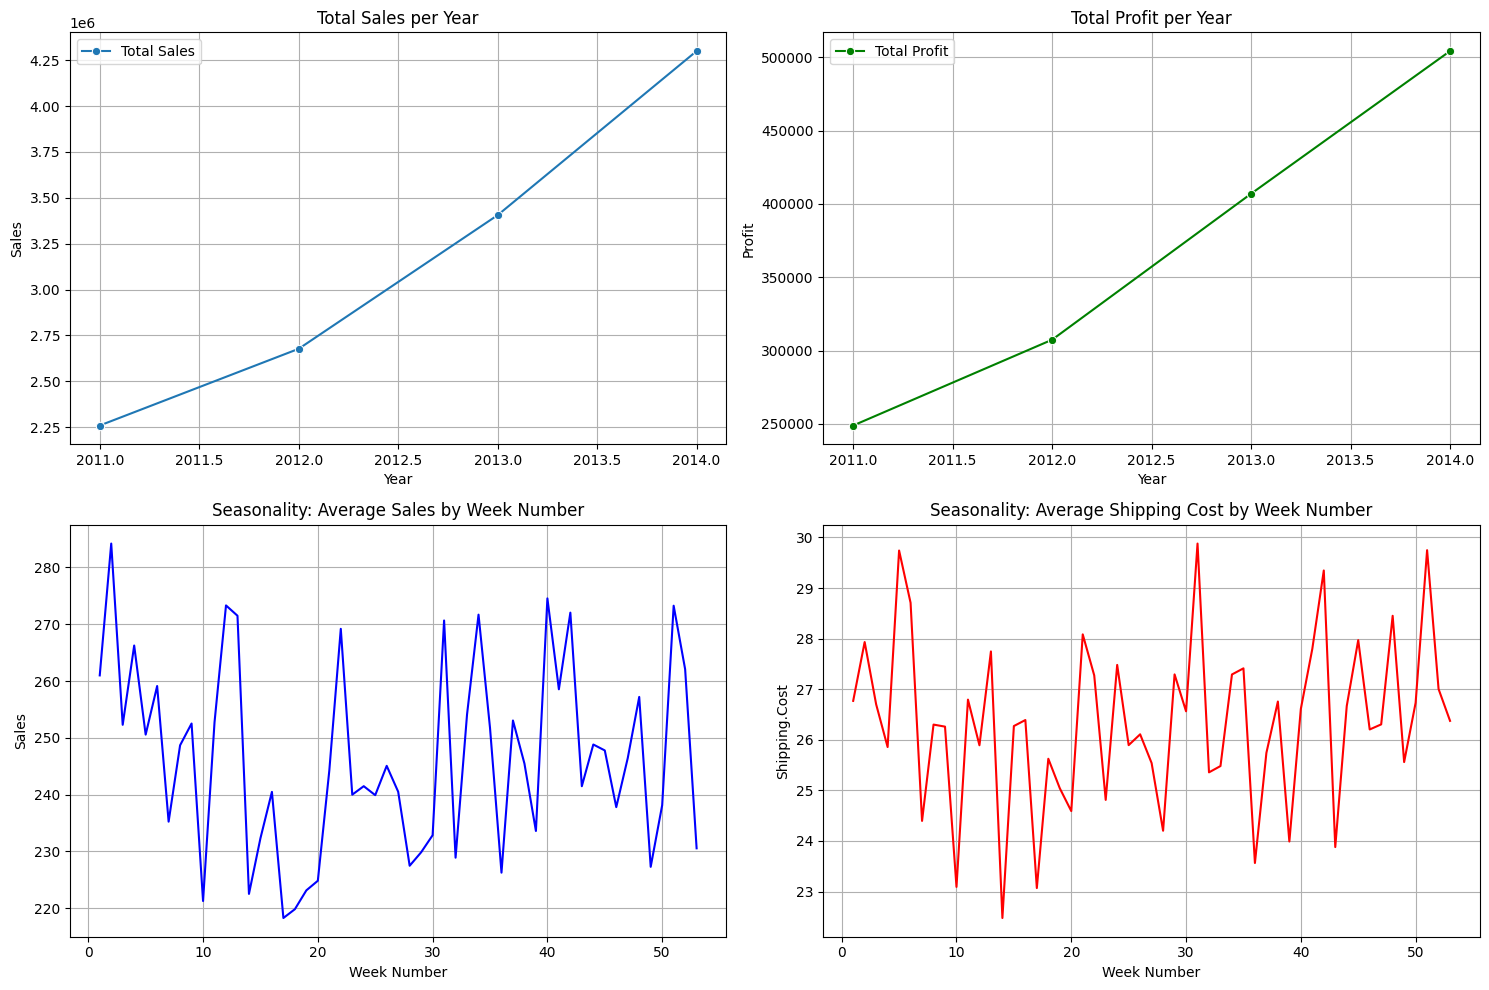

In [44]:
# 1. Yearly Trends
yearly_trends = df.groupby('Year').agg({'Sales': 'sum', 'Profit': 'sum', 'Shipping.Cost': 'mean'}).reset_index()

# 2. Weekly Trends
weekly_trends = df.groupby('weeknum').agg({'Sales': 'mean', 'Profit': 'mean', 'Shipping.Cost': 'mean'}).reset_index()

# Visualization
plt.figure(figsize=(15, 10))

# Subplot 1: Total Sales and Profit over Years
plt.subplot(2, 2, 1)
sns.lineplot(data=yearly_trends, x='Year', y='Sales', marker='o', label='Total Sales')
plt.title('Total Sales per Year')
plt.grid(True)

plt.subplot(2, 2, 2)
sns.lineplot(data=yearly_trends, x='Year', y='Profit', marker='o', color='green', label='Total Profit')
plt.title('Total Profit per Year')
plt.grid(True)

# Subplot 3: Average Sales by Week Number
plt.subplot(2, 2, 3)
sns.lineplot(data=weekly_trends, x='weeknum', y='Sales', color='blue')
plt.title('Seasonality: Average Sales by Week Number')
plt.xlabel('Week Number')
plt.grid(True)

# Subplot 4: Average Shipping Cost by Week Number
plt.subplot(2, 2, 4)
sns.lineplot(data=weekly_trends, x='weeknum', y='Shipping.Cost', color='red')
plt.title('Seasonality: Average Shipping Cost by Week Number')
plt.xlabel('Week Number')
plt.grid(True)

plt.tight_layout()

# Print Yearly data for precise insights
print("Yearly Summary:")
print(yearly_trends)

# Check for specific high-activity weeks
top_weeks = weekly_trends.sort_values(by='Sales', ascending=False).head(5)
print("\nTop 5 Weeks by Average Sales:")
print(top_weeks)

***Q5: Perform Bi-variant Analysis for categorical to numerical features.:***

Q5 i. Profi t by Category: Which category has the highest median profi t? Which has the lowest? Which category shows the widest spread (largest IQR) in Profit? What does that suggest about profit consistency?

Profit Statistics by Category:
                     50%     25%    75%     IQR
Category                                       
Furniture        15.5022 -12.175  69.36  81.535
Office Supplies   6.5538   0.450  20.58  20.130
Technology       29.9400   0.500  98.85  98.350


Text(0, 0.5, 'Profit')

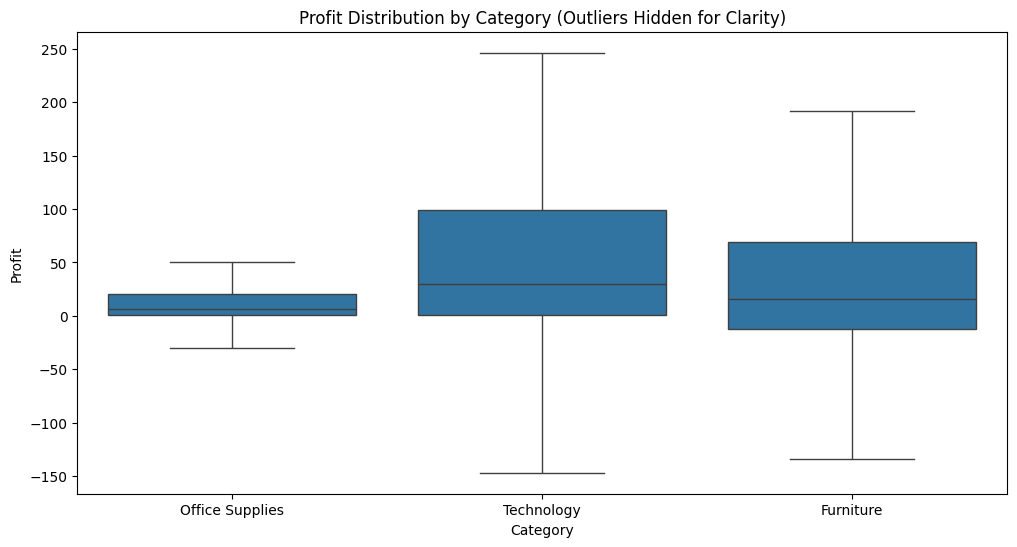

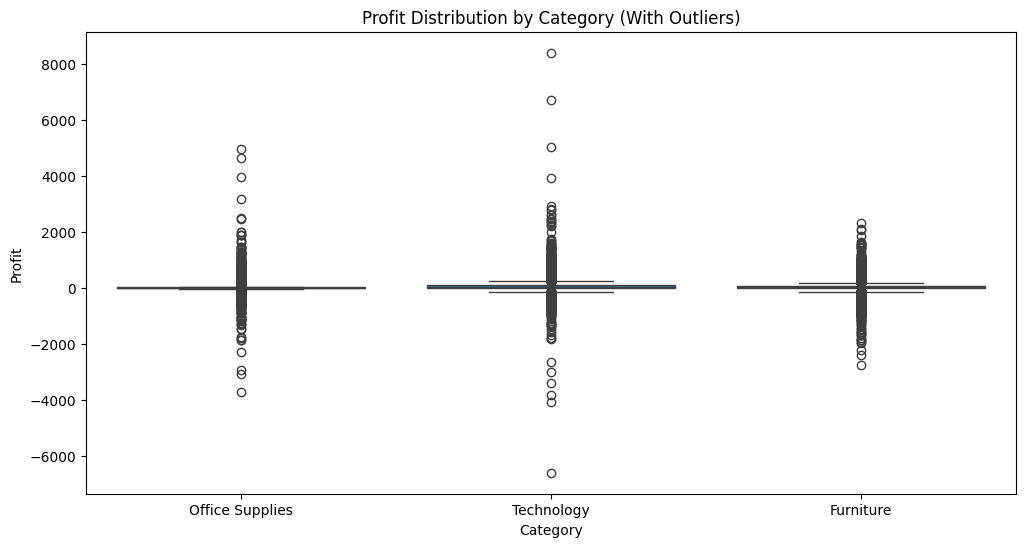

In [45]:
profit_stats = df.groupby('Category')['Profit'].describe(percentiles=[0.25, 0.5, 0.75])
profit_stats['IQR'] = profit_stats['75%'] - profit_stats['25%']

print("Profit Statistics by Category:")
print(profit_stats[['50%', '25%', '75%', 'IQR']])

plt.figure(figsize=(12, 6))
sns.boxplot(x='Category', y='Profit', data=df, showfliers=False)
plt.title('Profit Distribution by Category (Outliers Hidden for Clarity)')
plt.ylabel('Profit')

plt.figure(figsize=(12, 6))
sns.boxplot(x='Category', y='Profit', data=df)
plt.title('Profit Distribution by Category (With Outliers)')
plt.ylabel('Profit')

**Profit is most consistent in Technology category**

Q5 ii. Sales by Category: Which category has the highest median sales? Does it also have the highest median profit?

Median Sales and Profit by Category:
                 Sales   Profit
Category                       
Technology       260.0  29.9400
Furniture        220.0  15.5022
Office Supplies   46.0   6.5538


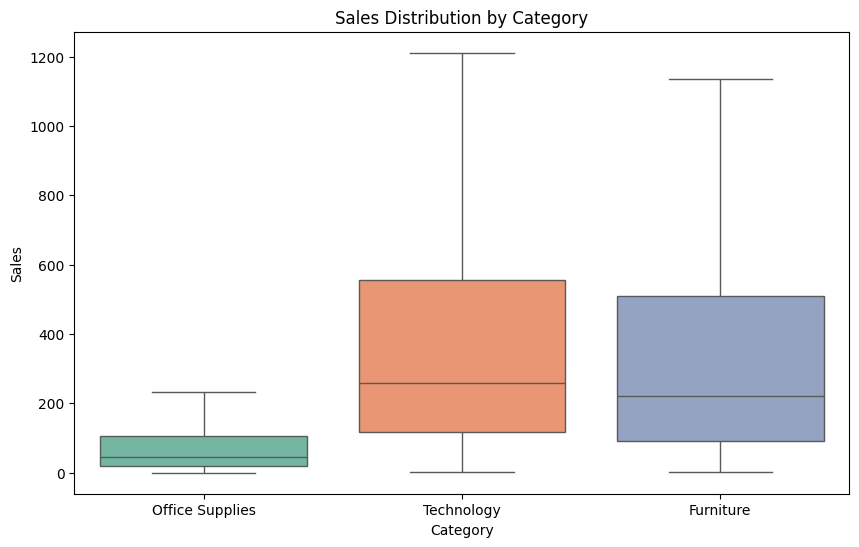

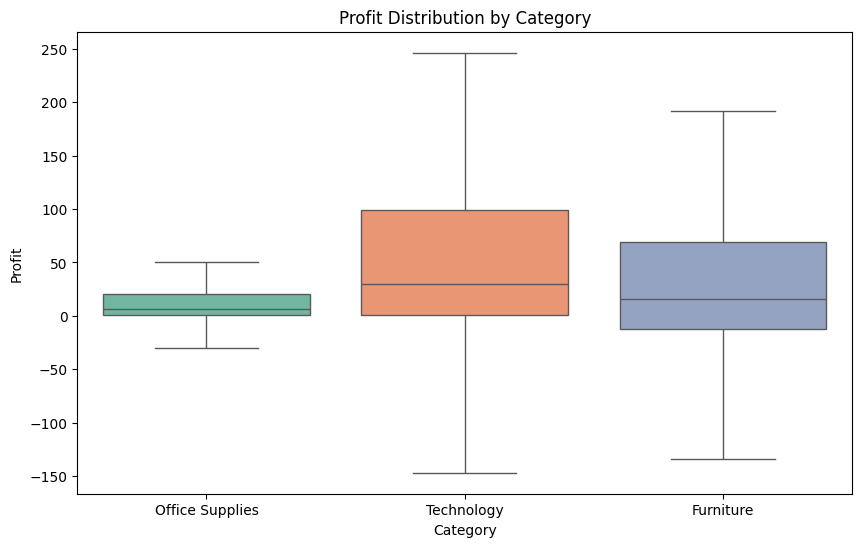

In [46]:
category_stats = df.groupby('Category').agg({
    'Sales': 'median',
    'Profit': 'median'
}).sort_values(by='Sales', ascending=False)

print("Median Sales and Profit by Category:")
print(category_stats)

# 1. Sales by Category (Updated to fix warning)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Sales', data=df, showfliers=False,
            hue='Category', palette='Set2', legend=False) # Added hue and legend=False
plt.title('Sales Distribution by Category')
plt.show()

# 2. Profit by Category (Updated to fix warning)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Profit', data=df, showfliers=False,
            hue='Category', palette='Set2', legend=False) # Added hue and legend=False
plt.title('Profit Distribution by Category')
plt.show()

**Technology category has the highest median sales and profit.**

Q5 iii. Profit by Segment: Which segment has the highest median profit? Which segment has the most negative/low profit outliers?

Median Profit by Segment:
Segment
Home Office    9.3200
Corporate      9.3152
Consumer       9.1800
Name: Profit, dtype: float64

Number of Negative/Low Profit Outliers by Segment:
Consumer       1834
Corporate      1081
Home Office     614
dtype: int64


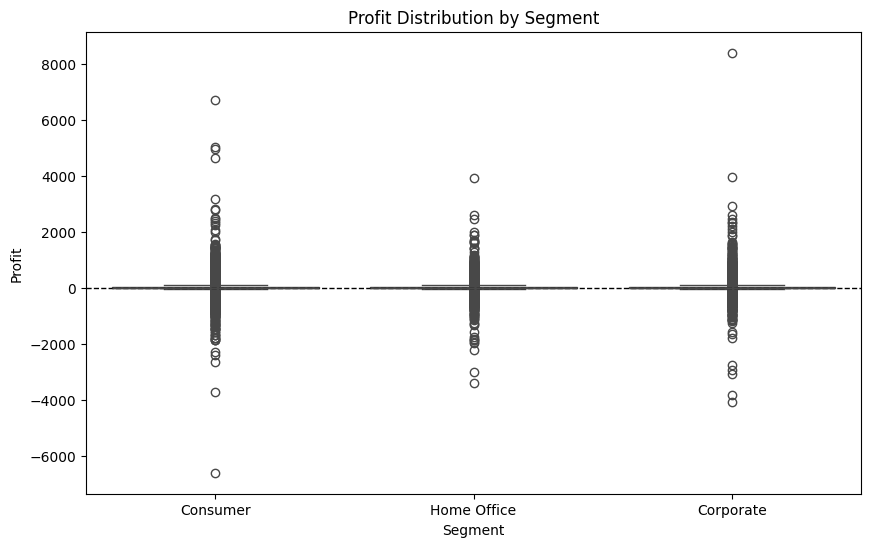

In [47]:
# 1. Median Profit by Segment
segment_stats = df.groupby('Segment')['Profit'].median().sort_values(ascending=False)
print("Median Profit by Segment:")
print(segment_stats)

# 2. Identify Negative/Low Outliers per Segment
segments = df['Segment'].unique()
low_outlier_counts = {}

for segment in segments:
    segment_data = df[df['Segment'] == segment]['Profit']
    Q1 = segment_data.quantile(0.25)
    Q3 = segment_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR

    # Count outliers below the lower bound
    low_outliers = segment_data[segment_data < lower_bound]
    low_outlier_counts[segment] = len(low_outliers)

low_outlier_df = pd.Series(low_outlier_counts).sort_values(ascending=False)
print("\nNumber of Negative/Low Profit Outliers by Segment:")
print(low_outlier_df)

# 3. Visualization
plt.figure(figsize=(10, 6))
sns.boxplot(x='Segment', y='Profit', data=df, hue='Segment', palette='Set1')
plt.title('Profit Distribution by Segment')
plt.ylabel('Profit')
plt.axhline(0, color='black', linestyle='--', linewidth=1)

# Check if legend exists before trying to remove it
legend = plt.gca().get_legend()
if legend:
    legend.remove()


Q5 iv. Sales by Segment: Which segment has the highest median sales? Is the profit pattern consistent with sales?

Median Sales and Profit by Segment:
             Sales  Profit
Segment                   
Consumer      85.0  9.1800
Corporate     85.0  9.3152
Home Office   85.0  9.3200


Text(0, 0.5, 'Profit')

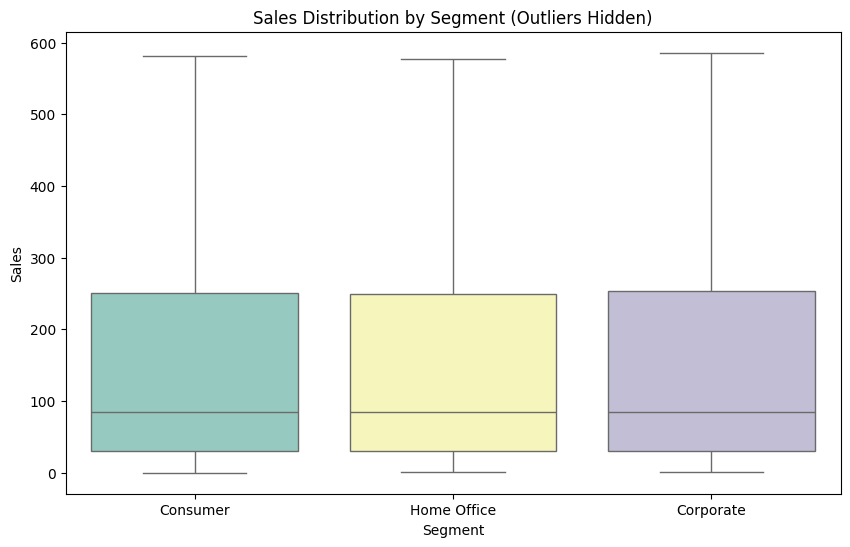

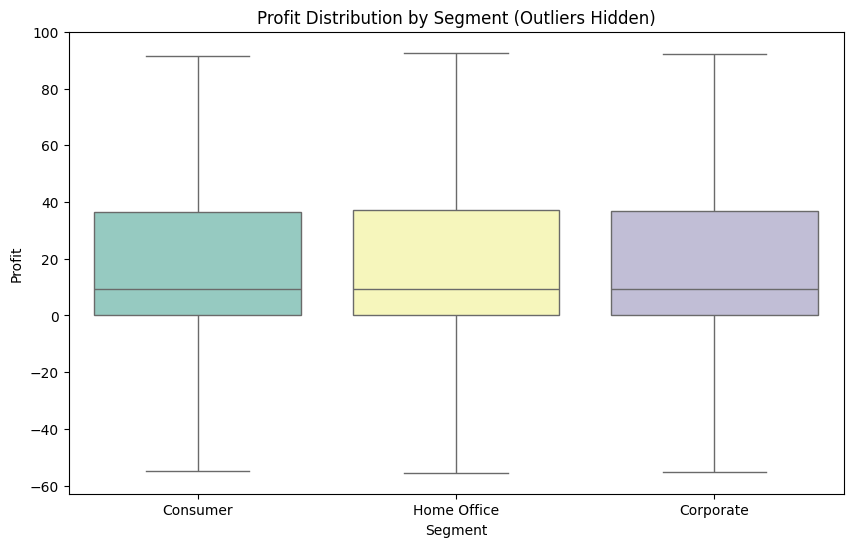

In [48]:
segment_stats = df.groupby('Segment').agg({
    'Sales': 'median',
    'Profit': 'median'
}).sort_values(by='Sales', ascending=False)

print("Median Sales and Profit by Segment:")
print(segment_stats)

# Visualizing Sales by Segment
plt.figure(figsize=(10, 6))
sns.boxplot(x='Segment', y='Sales', data=df, showfliers=False, hue='Segment', palette='Set3')
plt.title('Sales Distribution by Segment (Outliers Hidden)')
plt.ylabel('Sales')

# Visualizing Profit by Segment for consistency check
plt.figure(figsize=(10, 6))
sns.boxplot(x='Segment', y='Profit', data=df, showfliers=False, hue='Segment', palette='Set3')
plt.title('Profit Distribution by Segment (Outliers Hidden)')
plt.ylabel('Profit')

***Q6: Perform Bivariate Analysis for Market features against Region, Category, and Country:***

Q6 i. Is the Market is not randomly spread across all Regions?

Crosstab of Market vs Region:
Region  Africa  Canada  Caribbean  Central  Central Asia  EMEA  East  North  \
Market                                                                        
APAC         0       0          0        0          2048     0     0      0   
Africa    4587       0          0        0             0     0     0      0   
Canada       0     384          0        0             0     0     0      0   
EMEA         0       0          0        0             0  5029     0      0   
EU           0       0          0     5822             0     0     0   2141   
LATAM        0       0       1690     2972             0     0     0   2644   
US           0       0          0     2323             0     0  2848      0   

Region  North Asia  Oceania  South  Southeast Asia  West  
Market                                                    
APAC          2338     3487      0            3129     0  
Africa           0        0      0               0     0  
Canada           0    

Text(0.5, 1.0, 'Bivariate Analysis: Market vs Region')

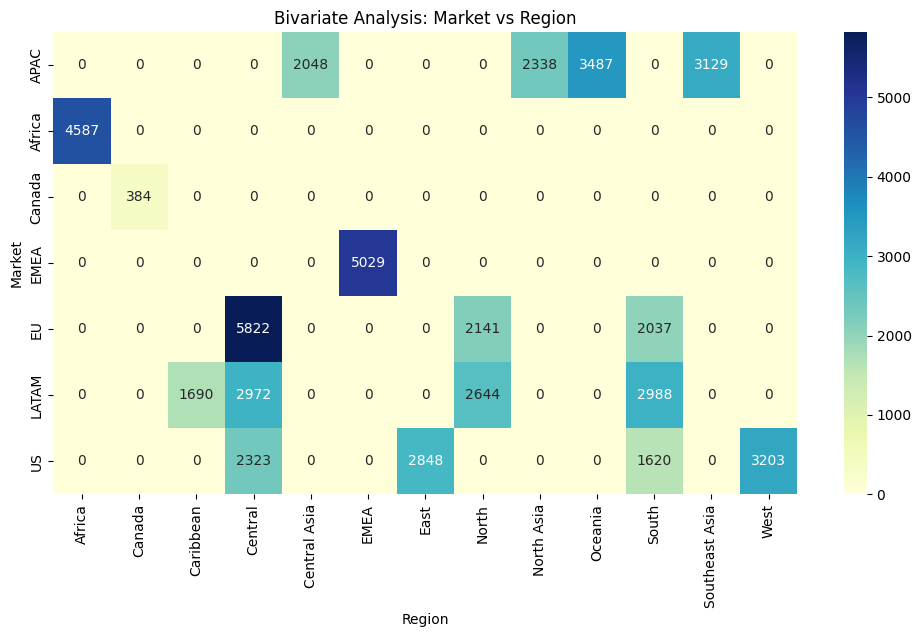

In [49]:
market_region_ct = pd.crosstab(df['Market'], df['Region'])

print("Crosstab of Market vs Region:")
print(market_region_ct)

# Check if each Region belongs to only one Market
regions_per_market = df.groupby('Region')['Market'].nunique()
print("\nNumber of Markets per Region:")
print(regions_per_market)

# Visualization: Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(market_region_ct, annot=True, fmt="d", cmap="YlGnBu")
plt.title('Bivariate Analysis: Market vs Region')

Q6 ii. Which country has negligible office supply orders?

In [50]:
# Filter for Office Supplies and count by country
office_supplies = df[df['Category'] == 'Office Supplies']
country_counts = office_supplies['Country'].value_counts(ascending=True)

# Display the countries with the fewest orders
print("Countries with the lowest Office Supply orders:")
print(country_counts.head(10))

Countries with the lowest Office Supply orders:
Country
Eritrea              1
Armenia              1
Swaziland            1
Bahrain              1
Chad                 2
Lesotho              2
Guadeloupe           2
Slovenia             2
Equatorial Guinea    2
Tajikistan           2
Name: count, dtype: int64


Q6 iii. What are the most useful insights?

In [51]:
table_profit = df[df['Sub.Category'] == 'Tables']['Profit'].mean()
print(f"Average Profit for Tables: {table_profit:.2f}")

# 2. Summary of Discount Impact
discount_bins = pd.cut(df['Discount'], bins=[0, 0.2, 1.0])
discount_impact = df.groupby(discount_bins, observed=False)['Profit'].mean()
print("\nProfitability by Discount Range:")
print(discount_impact)

# 3. Market Efficiency
market_eff = (df.groupby('Market')['Profit'].sum() / df.groupby('Market').size()).sort_values(ascending=False)
print("\nProfit per Order by Market:")
print(market_eff)

Average Profit for Tables: -74.43

Profitability by Discount Range:
Discount
(0.0, 0.2]    46.694431
(0.2, 1.0]   -71.917557
Name: Profit, dtype: float64

Profit per Order by Market:
Market
Canada    46.399453
APAC      39.629163
EU        37.282974
US        28.656896
LATAM     21.531328
Africa    19.374674
EMEA       8.728966
dtype: float64
